# Image Classification Using Convolutional Neural Networks (CNNs)

## Dataset: CIFAR-10

### Objective

Build an Enhanced CNN model to classify images into 10 categories using deep learning techniques.

Technologies Used:
- Python
- TensorFlow/Keras
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

In [ ]:
## 1. Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [ ]:
## 2. Load Dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


In [ ]:
## 3. Explore Dataset
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

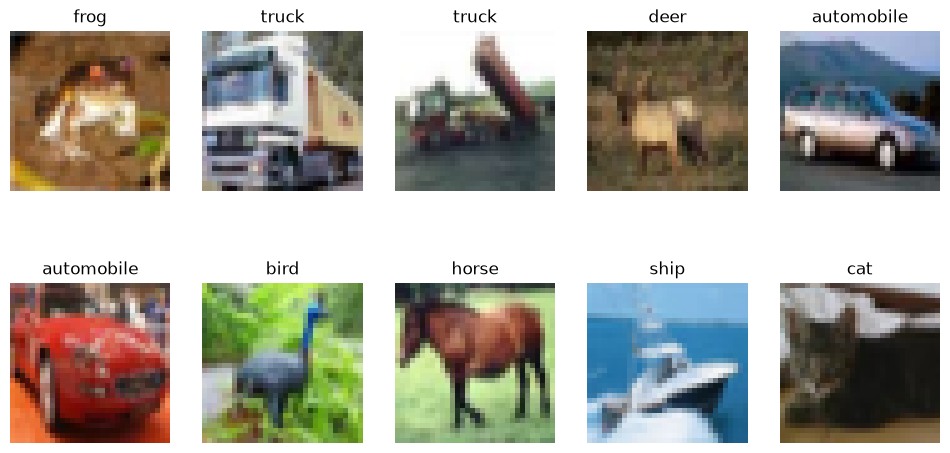

In [ ]:
## 4. Image Preprocessing
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(x_train[i])

    plt.title(class_names[y_train[i][0]])

    plt.axis("off")

plt.show()

In [ ]:
## 5. Data Augmentation
x_train = x_train / 255.0

x_test = x_test / 255.0

In [ ]:
## 6. Enhanced CNN Architecture
x_train_final, x_val, y_train_final, y_val = train_test_split(

    x_train,

    y_train,

    test_size=0.2,

    random_state=42,

    stratify=y_train

)

print(x_train_final.shape)

print(x_val.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
## 7. Model Compilation
datagen = ImageDataGenerator(

    rotation_range=15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    horizontal_flip=True

)

datagen.fit(x_train_final)

In [8]:
from tensorflow.keras.regularizers import l2

model = Sequential()

# Block 1

model.add(Conv2D(64,(3,3),
                 padding='same',
                 activation='relu',
                 input_shape=(32,32,3)))

model.add(BatchNormalization())

model.add(Conv2D(64,(3,3),
                 padding='same',
                 activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.25))

# Block 2

model.add(Conv2D(128,(3,3),
                 padding='same',
                 activation='relu'))

model.add(BatchNormalization())

model.add(Conv2D(128,(3,3),
                 padding='same',
                 activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.30))

# Block 3

model.add(Conv2D(256,(3,3),
                 padding='same',
                 activation='relu'))

model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

model.add(Dropout(0.40))

# Classifier

model.add(Flatten())

model.add(Dense(256,
                activation='relu',
                kernel_regularizer=l2(0.001)))

model.add(Dropout(0.5))

model.add(Dense(10,
                activation='softmax'))

c:\Users\aakan\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,609,290 (6.14 MB)

 Trainable params: 1,608,010 (6.13 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [10]:
model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(

    monitor='val_loss',

    patience=7,

    restore_best_weights=True
)

In [12]:
history = model.fit(

    datagen.flow(

        x_train_final,

        y_train_final,

        batch_size=64

    ),

    epochs=30,

    validation_data=(x_val,y_val),

    callbacks=[early_stop]

)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 222s 340ms/step - accuracy: 0.3297 - loss: 2.2784 - val_accuracy: 0.4964 - val_loss: 1.6999
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 227s 364ms/step - accuracy: 0.4636 - loss: 1.7352 - val_accuracy: 0.2828 - val_loss: 2.7143
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.5360 - loss: 1.5212 - val_accuracy: 0.5906 - val_loss: 1.3892
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 296ms/step - accuracy: 0.5877 - loss: 1.3992 - val_accuracy: 0.6547 - val_loss: 1.2232
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 190s 303ms/step - accuracy: 0.6309 - loss: 1.3548 - val_accuracy: 0.6942 - val_loss: 1.1750
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 187s 299ms/step - accuracy: 0.6584 - loss: 1.3132 - val_accuracy: 0.6749 - val_loss: 1.3445
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 185s 296ms/step - accuracy: 0.6838 - loss: 1.2802 - val_accuracy: 0.6989 - val_loss: 1.2697
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.7015 -

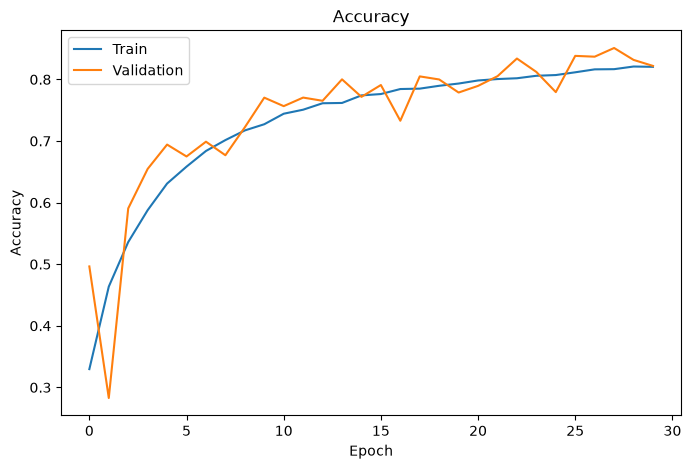

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.savefig("outputs/accuracy_plot.png")

plt.show()

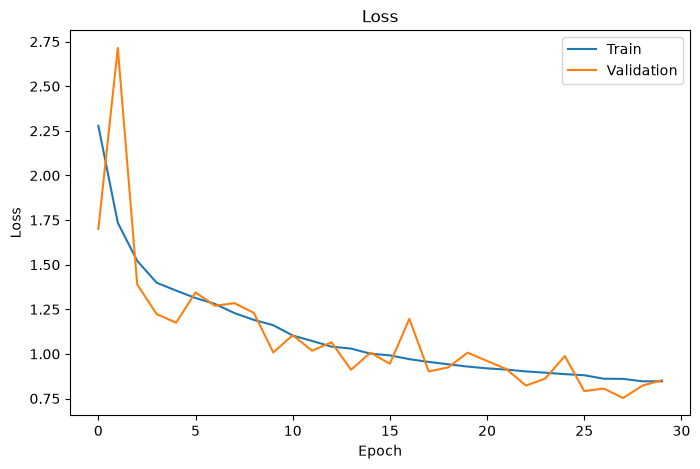

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title('Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.savefig("outputs/loss_plot.png")

plt.show()

In [15]:
test_loss,test_accuracy = model.evaluate(x_test,y_test)

print("Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.8466 - loss: 0.7685
Accuracy: 0.8465999960899353


In [16]:
predictions = model.predict(x_test)

predicted_labels = np.argmax(predictions,axis=1)

actual_labels = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step


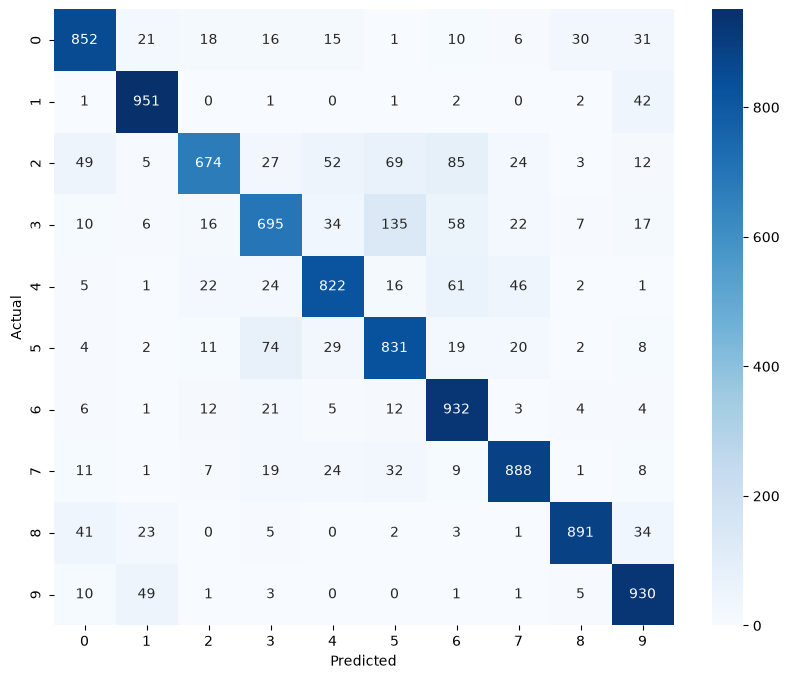

In [26]:
cm = confusion_matrix(actual_labels,predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues'

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("outputs/confusion_matrix.png")

plt.show()

In [18]:
print(

classification_report(

actual_labels,

predicted_labels,

target_names=class_names

)

)

              precision    recall  f1-score   support

    airplane       0.86      0.85      0.86      1000
  automobile       0.90      0.95      0.92      1000
        bird       0.89      0.67      0.77      1000
         cat       0.79      0.69      0.74      1000
        deer       0.84      0.82      0.83      1000
         dog       0.76      0.83      0.79      1000
        frog       0.79      0.93      0.86      1000
       horse       0.88      0.89      0.88      1000
        ship       0.94      0.89      0.92      1000
       truck       0.86      0.93      0.89      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.85      0.84     10000



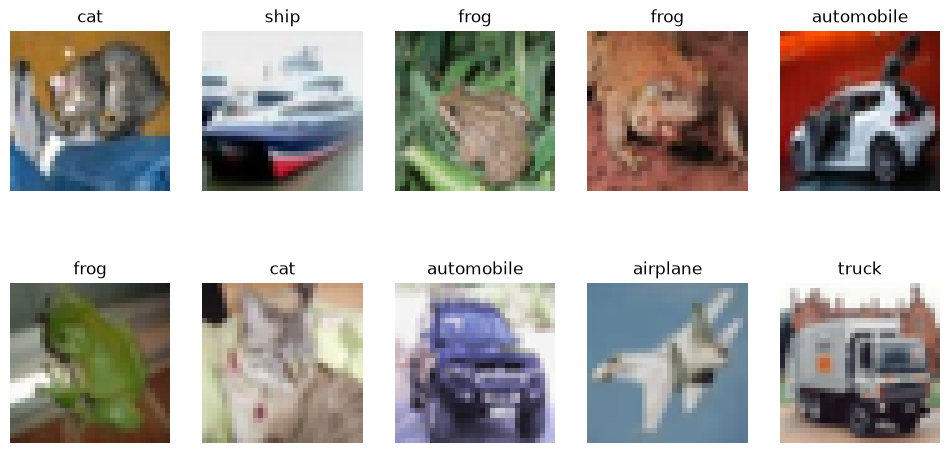

In [27]:
correct = np.where(predicted_labels==actual_labels)[0]

plt.figure(figsize=(12,6))

for i,index in enumerate(correct[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[index])

    plt.title(class_names[predicted_labels[index]])

    plt.axis("off")

plt.savefig("outputs/correct_predictions.png")

plt.show()

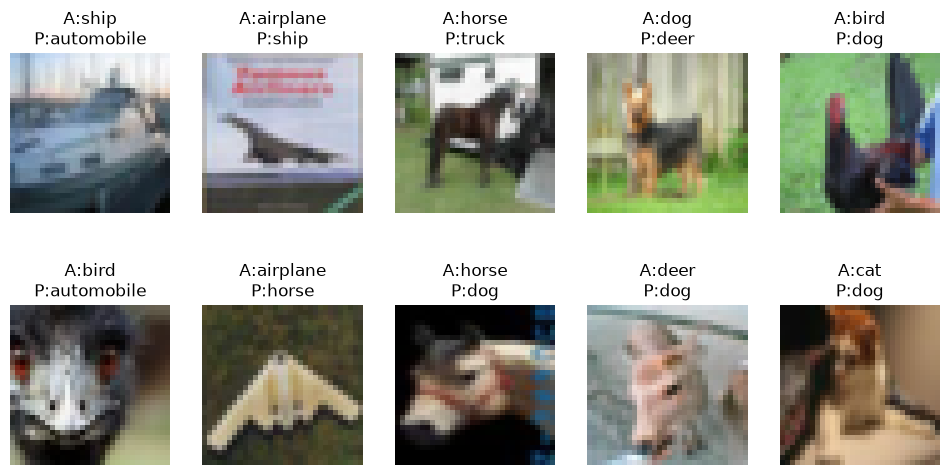

In [28]:
incorrect = np.where(predicted_labels!=actual_labels)[0]

plt.figure(figsize=(12,6))

for i,index in enumerate(incorrect[:10]):

    plt.subplot(2,5,i+1)

    plt.imshow(x_test[index])

    plt.title(

        f"A:{class_names[actual_labels[index]]}\n"

        f"P:{class_names[predicted_labels[index]]}"

    )

    plt.axis("off")

plt.savefig("outputs/incorrect_predictions.png")

plt.show()

In [21]:
model.save("saved_model/cnn_model.keras")

In [22]:
print("Epochs executed:", len(history.history['accuracy']))

print("Final Training Accuracy:", history.history['accuracy'][-1])

print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Epochs executed: 30
Final Training Accuracy: 0.8204249739646912
Final Validation Accuracy: 0.8219000101089478


In [31]:
print("========== PROJECT SUMMARY ==========")

print(f"Dataset: CIFAR-10")

print(f"Training Images: {len(x_train_final)}")

print(f"Validation Images: {len(x_val)}")

print(f"Testing Images: {len(x_test)}")

print(f"Final Test Accuracy: {test_accuracy:.2%}")

print("Model: Enhanced CNN")

print("====================================")

========== PROJECT SUMMARY ==========
Dataset: CIFAR-10
Training Images: 40000
Validation Images: 10000
Testing Images: 10000
Final Test Accuracy: 84.66%
Model: Enhanced CNN
